# Software Development Oriented to Machine Learning 

# Importing Libraries

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import layers

I0000 00:00:1789324665.855135  148488 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1789324665.949724  148488 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1789324667.729264  148488 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


# Loading and Exploring Data

In [2]:
#!uv pip install datasets
df = pd.read_parquet("hf://datasets/juliensimon/sentry-impact-risk/data/sentry_impact_risk.parquet")
df.head()

,torino_scale,n_potential_impacts,last_observation,designation,impact_probability,palermo_scale_cum,last_observation_jd,full_name,v_infinity_kms,absolute_magnitude,diameter_km,palermo_scale_max,year_range_min,year_range_max
0,NaN,1,2025-04-28,29075,3.770000e-04,-0.93,2.460794e+06,29075 (1950 DA),14.100000,17.94,1.300,-0.93,2880,2880
1,NaN,157,NaT,101955,5.717000e-04,-1.40,2.459126e+06,101955 Bennu (1999 RQ36),5.991698,20.63,0.490,-1.58,2178,2290
2,0.0,44,2008-05-09,2008 JL3,1.658148e-04,-2.38,2.454596e+06,(2008 JL3),8.419012,25.31,0.029,-2.39,2027,2122
3,0.0,4,1979-12-15,1979 XB,8.515158e-07,-2.69,2.444222e+06,(1979 XB),23.760623,18.54,0.660,-2.99,2056,2113
4,0.0,300,2000-10-03,2000 SG344,2.743395e-03,-2.76,2.451820e+06,(2000 SG344),1.358027,24.79,0.037,-3.11,2069,2122


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2202 entries, 0 to 2201
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   torino_scale         2200 non-null   float64       
 1   n_potential_impacts  2202 non-null   int64         
 2   last_observation     2201 non-null   datetime64[us]
 3   designation          2202 non-null   object        
 4   impact_probability   2202 non-null   float64       
 5   palermo_scale_cum    2202 non-null   float64       
 6   last_observation_jd  2202 non-null   float64       
 7   full_name            2202 non-null   object        
 8   v_infinity_kms       2198 non-null   float64       
 9   absolute_magnitude   2202 non-null   float64       
 10  diameter_km          2202 non-null   float64       
 11  palermo_scale_max    2202 non-null   float64       
 12  year_range_min       2202 non-null   Int64         
 13  year_range_max       2202 non-nul

In [4]:
df.isna().sum()
#df.dropna()

torino_scale           2
n_potential_impacts    0
last_observation       1
designation            0
impact_probability     0
palermo_scale_cum      0
last_observation_jd    0
full_name              0
v_infinity_kms         4
absolute_magnitude     0
diameter_km            0
palermo_scale_max      0
year_range_min         0
year_range_max         0
dtype: int64

# Data Preprocessing & Cleaning:

In [5]:

os.environ['CUDA_VISIBLE_DEVICES'] = '-1'  # Force CPU only


df_reg = df.copy()
df_reg = df_reg.dropna() 
df_reg['log_impact_probability'] = np.log10(df_reg['impact_probability'])

# Data loading and preprocessing
features = df.select_dtypes(include=['number']).columns.tolist()
features.remove('impact_probability')
X = df_reg[features]
y = df_reg['log_impact_probability']
scaler = StandardScaler()

X_processed = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

# Feature Engineering

# Baseline Model Development

In [6]:
# Model definition
model = tf.keras.Sequential([
    layers.Input(shape=[len(X.keys())]),
    layers.Dense(64, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(1)
])

# Loss, optimizer, and metrics
optimizer = tf.keras.optimizers.Adam()#.RMSprop(0.001)
model.compile(optimizer=optimizer, loss='mse', metrics=['mae']) #metrics=['mae', 'mse']

# Training
history = model.fit(X_train, y_train, epochs=10, batch_size=64, validation_split=0.1, verbose=2)

# Evaluation
test_loss, test_mae = model.evaluate(X_test, y_test,batch_size=30, verbose=0)
print(f"Test MSE (Loss): {test_loss:.4f}")
print(f"Test MAE (Mean Absolute Error): {test_mae:.4f}")


Epoch 1/10


E0000 00:00:1789322265.327020  142628 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


25/25 - 2s - 92ms/step - loss: 27.7349 - mae: 5.0150 - val_loss: 20.1623 - val_mae: 4.1992
Epoch 2/10
25/25 - 0s - 12ms/step - loss: 12.5916 - mae: 3.1414 - val_loss: 8.3255 - val_mae: 2.3176
Epoch 3/10
25/25 - 0s - 14ms/step - loss: 4.4009 - mae: 1.6177 - val_loss: 3.5701 - val_mae: 1.3049
Epoch 4/10
25/25 - 0s - 11ms/step - loss: 2.4719 - mae: 1.1779 - val_loss: 2.2455 - val_mae: 1.1018
Epoch 5/10
25/25 - 0s - 8ms/step - loss: 1.7703 - mae: 1.0213 - val_loss: 1.6455 - val_mae: 0.9551
Epoch 6/10
25/25 - 0s - 8ms/step - loss: 1.3315 - mae: 0.8962 - val_loss: 1.1242 - val_mae: 0.8132
Epoch 7/10
25/25 - 0s - 7ms/step - loss: 1.0202 - mae: 0.7812 - val_loss: 0.8613 - val_mae: 0.7264
Epoch 8/10
25/25 - 0s - 8ms/step - loss: 0.8246 - mae: 0.7059 - val_loss: 0.6929 - val_mae: 0.6639
Epoch 9/10
25/25 - 0s - 9ms/step - loss: 0.6987 - mae: 0.6537 - val_loss: 0.5771 - val_mae: 0.6121
Epoch 10/10
25/25 - 0s - 9ms/step - loss: 0.6042 - mae: 0.6084 - val_loss: 0.5066 - val_mae: 0.5702
Test MSE (Los

# Advanced Training & Evaluation

# Results and Conclusion

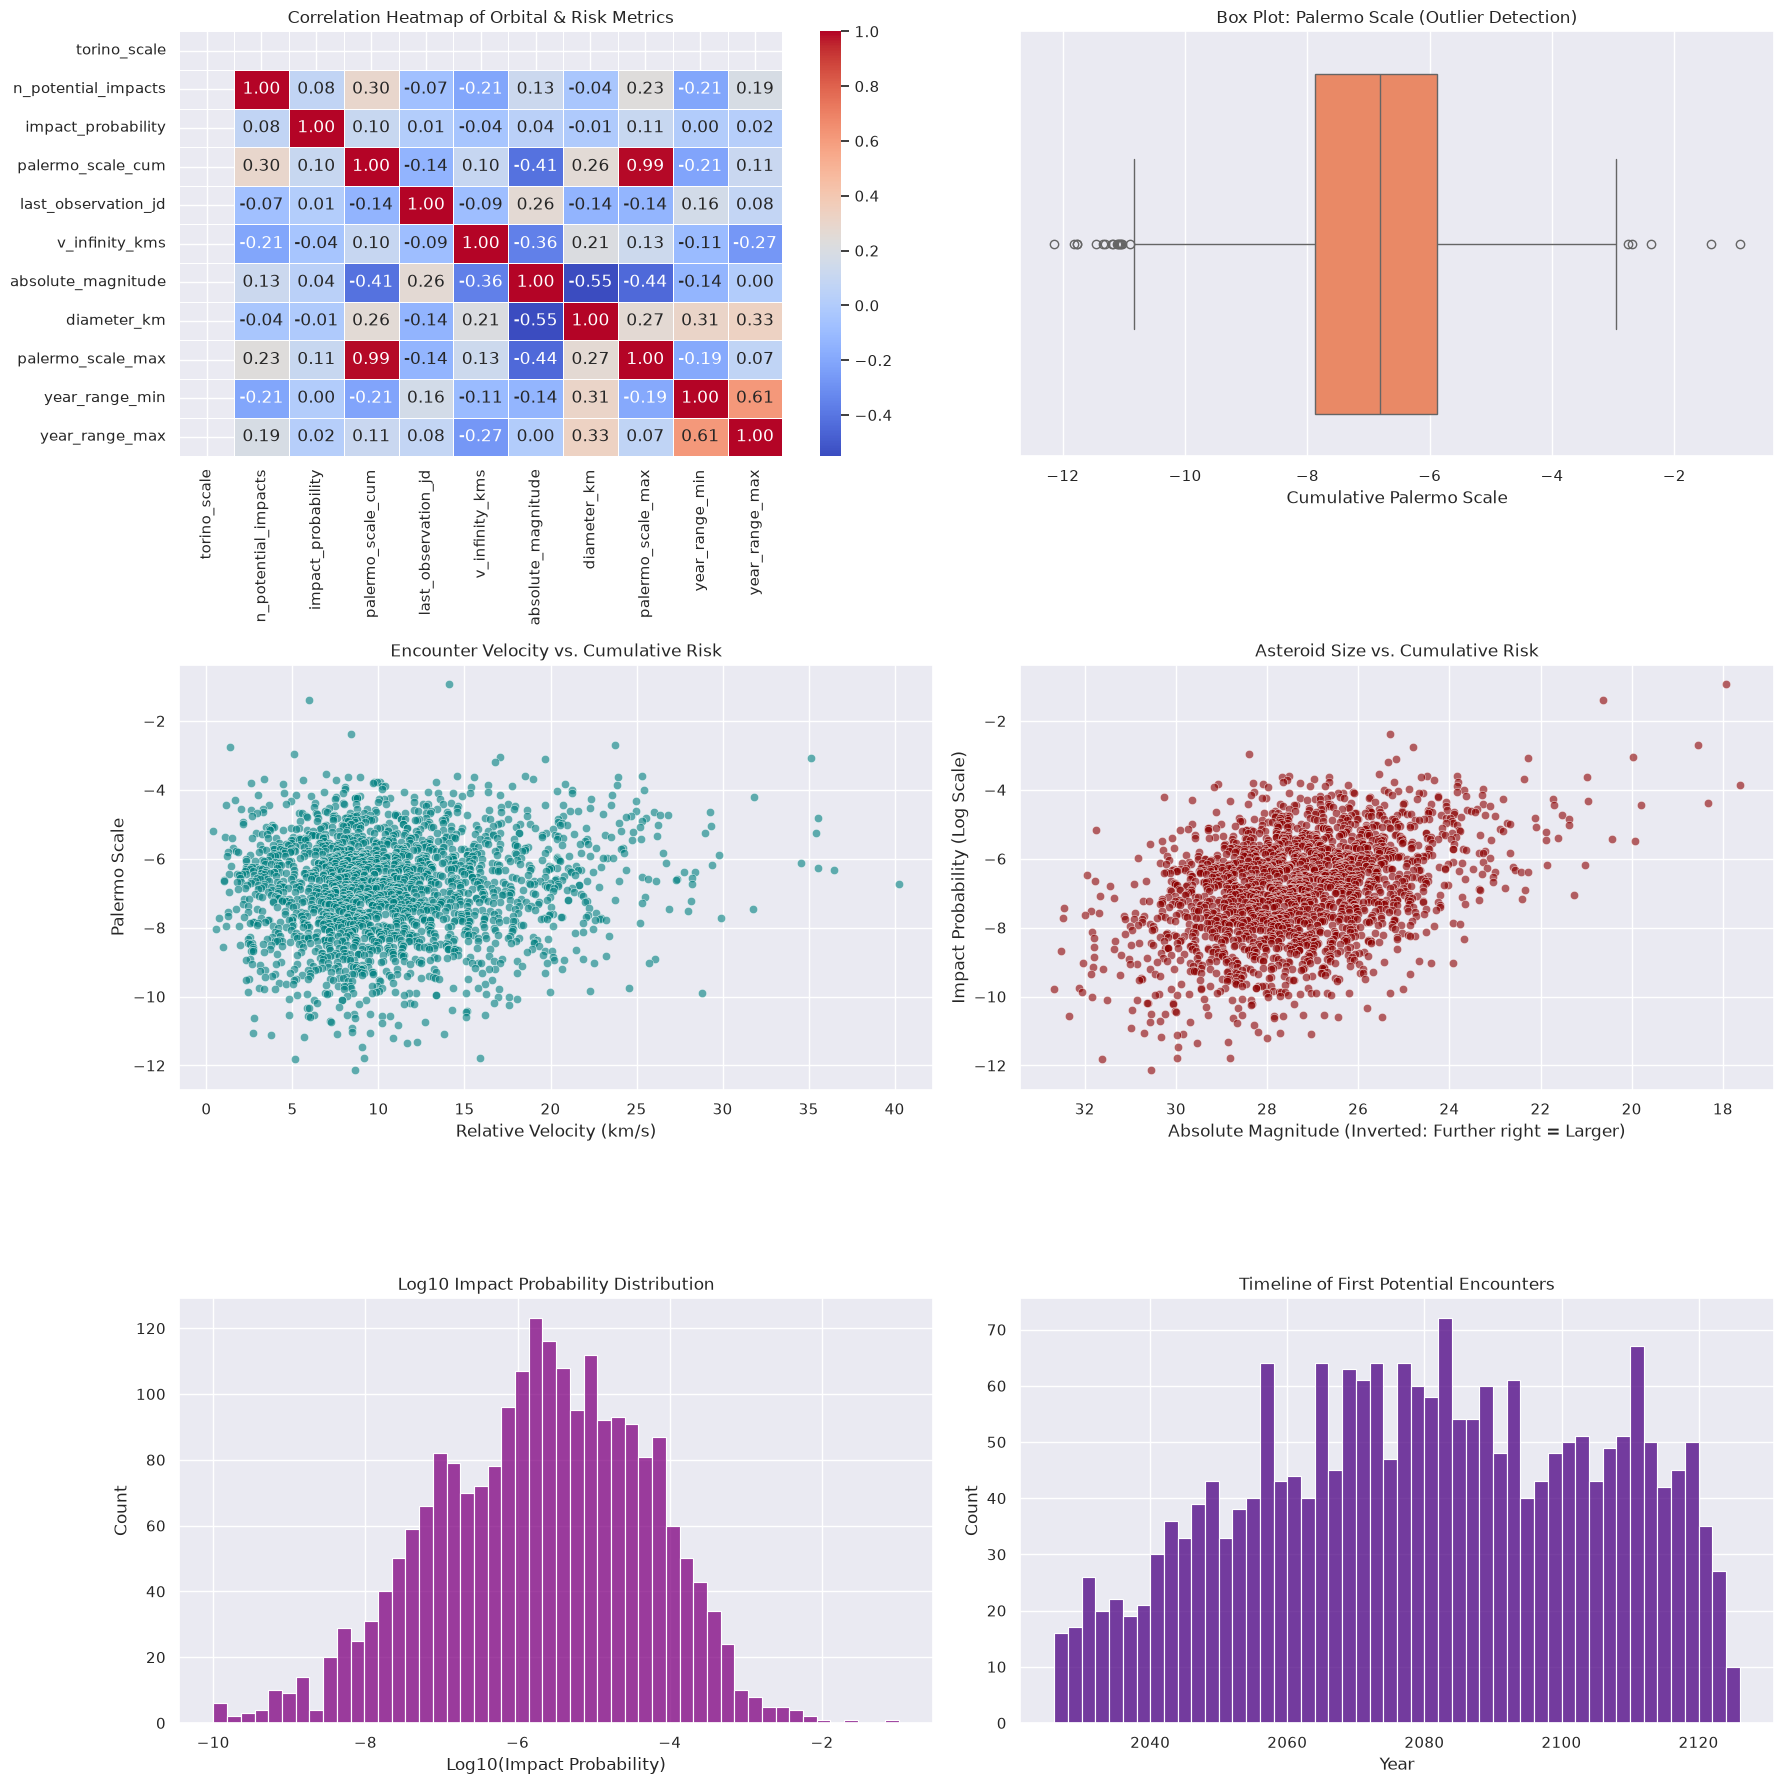

In [7]:
sns.set_theme(style="darkgrid")
fig, axes = plt.subplots(3, 2, figsize=(18, 18))

# Chart 1: Correlation Heatmap
# Select only numerical columns to find mathematical relationships
numeric_cols = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f", 
            linewidths=0.5, ax=axes[0, 0])
axes[0, 0].set_title('Correlation Heatmap of Orbital & Risk Metrics')

sns.boxplot(x=df['palermo_scale_cum'], ax=axes[0, 1], color='coral')
axes[0, 1].set_title('Box Plot: Palermo Scale (Outlier Detection)')
axes[0, 1].set_xlabel('Cumulative Palermo Scale')

sns.scatterplot(data=df, x='v_infinity_kms', y='palermo_scale_cum', 
                alpha=0.6, ax=axes[1, 0], color='teal')
axes[1, 0].set_title('Encounter Velocity vs. Cumulative Risk')
axes[1, 0].set_xlabel('Relative Velocity (km/s)')
axes[1, 0].set_ylabel('Palermo Scale')

#Chart 5: Scatter Plot - Size vs. Impact Probability
sns.scatterplot(data=df, x='absolute_magnitude', y='palermo_scale_cum', 
                alpha=0.6, ax=axes[1, 1], color='darkred')
axes[1, 1].invert_xaxis()
axes[1, 1].set_title('Asteroid Size vs. Cumulative Risk')
axes[1, 1].set_xlabel('Absolute Magnitude (Inverted: Further right = Larger)')
axes[1, 1].set_ylabel('Impact Probability (Log Scale)')

# Chart 4: Logarithmic Histogram - Impact Probability
# We apply log10 because probabilities are extremely small (e.g., 0.00001)
sns.histplot(df['impact_probability'].apply(np.log10), bins=50, ax=axes[2, 0], color='purple')
axes[2, 0].set_title('Log10 Impact Probability Distribution')
axes[2, 0].set_xlabel('Log10(Impact Probability)')


# Chart 6: Histogram - Timeline of Risks
sns.histplot(df['year_range_min'].dropna(), bins=50, binrange=(2026, 2126), ax=axes[2, 1], color='indigo')
axes[2, 1].set_title('Timeline of First Potential Encounters')
axes[2, 1].set_xlabel('Year')

plt.tight_layout()
plt.show()

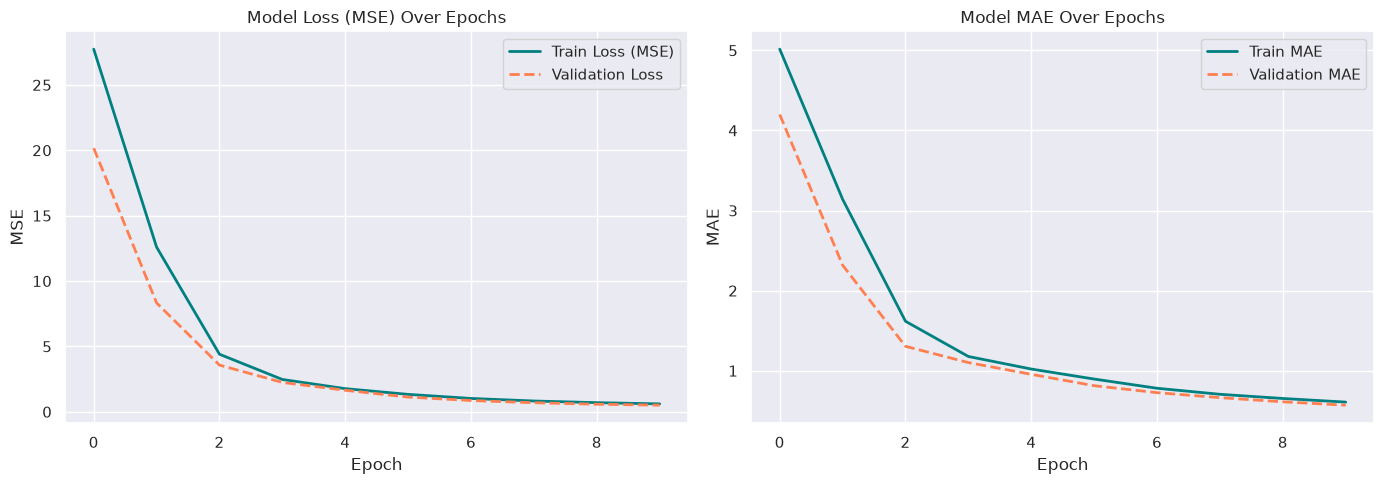

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de Loss (MSE)
ax1.plot(history.history['loss'], label='Train Loss (MSE)', color='teal', linewidth=2)
if 'val_loss' in history.history:
    ax1.plot(history.history['val_loss'], label='Validation Loss', color='coral', linewidth=2, linestyle='--')
ax1.set_title('Model Loss (MSE) Over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('MSE')
ax1.legend()

# Gráfico de MAE (Reemplaza al Accuracy)
ax2.plot(history.history['mae'], label='Train MAE', color='teal', linewidth=2)
if 'val_mae' in history.history:
    ax2.plot(history.history['val_mae'], label='Validation MAE', color='coral', linewidth=2, linestyle='--')
ax2.set_title('Model MAE Over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('MAE')
ax2.legend()

plt.tight_layout()
#plt.savefig(os.path.join(output_dir, 'training_history.png'), dpi=300)
plt.show()